In [2]:
import numpy as np
import matplotlib.pylab as pl
import ot

### Generate data

In [3]:
n = 40  # nb samples

mu_s = np.array([-1, -1])
cov_s = np.array([[1, 0], [0, 1]])

mu_t = np.array([4, 4])
cov_t = np.array([[1, -0.8], [-0.8, 1]])

np.random.seed(0)
xs = ot.datasets.make_2D_samples_gauss(n, mu_s, cov_s)
xt = ot.datasets.make_2D_samples_gauss(n, mu_t, cov_t)

n_noise = 10

xs = np.concatenate((xs, (np.random.rand(n_noise, 2) - 4)), axis=0)
xt = np.concatenate((xt, (np.random.rand(n_noise, 2) + 6)), axis=0)

n = n + n_noise

a, b = np.ones((n,)) / n, np.ones((n,)) / n  # uniform distribution on samples

# loss matrix
M = ot.dist(xs, xt)
M /= M.max()

### Compute entropic KL-regularized UOT, KL- and L2-regularized UOT

In [4]:
reg = 0.005
reg_m_kl = 0.05
reg_m_l2 = 5
mass = 0.7

entropic_kl_uot = ot.unbalanced.sinkhorn_unbalanced(a, b, M, reg, reg_m_kl)
kl_uot = ot.unbalanced.mm_unbalanced(a, b, M, reg_m_kl, div="kl")
l2_uot = ot.unbalanced.mm_unbalanced(a, b, M, reg_m_l2, div="l2")
partial_ot = ot.partial.partial_wasserstein(a, b, M, m=mass)

### Plot the results

<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_213982/3762627072.py:5: SyntaxWarning: invalid escape sequence '\e'
  "$\ell_2$-UOT \n $\mathrm{reg_m}$=" + str(reg_m_l2),
/tmp/ipykernel_213982/3762627072.py:6: SyntaxWarning: invalid escape sequence '\m'
  "kl-UOT \n $\mathrm{reg_m}$=" + str(reg_m_kl),
/tmp/ipykernel_213982/3762627072.py:7: SyntaxWarning: invalid escape sequence '\m'
  "entropic kl-UOT \n $\mathrm{reg_m}$=" + str(reg_m_kl),


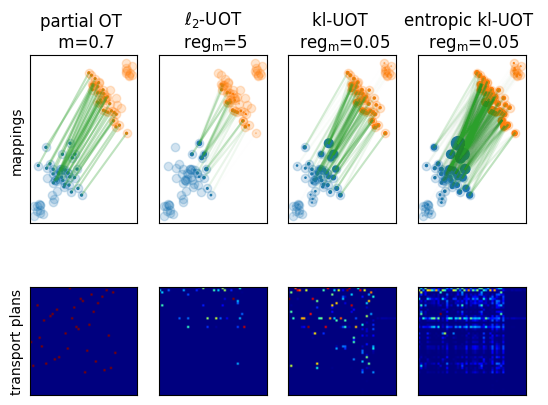

In [5]:
pl.figure(2)
transp = [partial_ot, l2_uot, kl_uot, entropic_kl_uot]
title = [
    "partial OT \n m=" + str(mass),
    "$\ell_2$-UOT \n $\mathrm{reg_m}$=" + str(reg_m_l2),
    "kl-UOT \n $\mathrm{reg_m}$=" + str(reg_m_kl),
    "entropic kl-UOT \n $\mathrm{reg_m}$=" + str(reg_m_kl),
]

for p in range(4):
    pl.subplot(2, 4, p + 1)
    P = transp[p]
    if P.sum() > 0:
        P = P / P.max()
    for i in range(n):
        for j in range(n):
            if P[i, j] > 0:
                pl.plot(
                    [xs[i, 0], xt[j, 0]],
                    [xs[i, 1], xt[j, 1]],
                    color="C2",
                    alpha=P[i, j] * 0.3,
                )
    pl.scatter(xs[:, 0], xs[:, 1], c="C0", alpha=0.2)
    pl.scatter(xt[:, 0], xt[:, 1], c="C1", alpha=0.2)
    pl.scatter(xs[:, 0], xs[:, 1], c="C0", s=P.sum(1).ravel() * (1 + p) * 2)
    pl.scatter(xt[:, 0], xt[:, 1], c="C1", s=P.sum(0).ravel() * (1 + p) * 2)
    pl.title(title[p])
    pl.yticks(())
    pl.xticks(())
    if p < 1:
        pl.ylabel("mappings")
    pl.subplot(2, 4, p + 5)
    pl.imshow(P, cmap="jet")
    pl.yticks(())
    pl.xticks(())
    if p < 1:
        pl.ylabel("transport plans")
pl.show()